<a href="https://colab.research.google.com/github/sajjaporn-sr/My-coursework/blob/main/SS_Anomaly_Detection_using_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Description**: An anomaly detection model using autoencoder architecture (Encoder-Decoder) is trained to reconstruct normal data patterns, allowing it to identify anomalies based on high reconstruction errors.

**Tools Used**: Python, Pandas, Numpy, Scikit-Learn, Tensorflow, Matplotlib, Seaborn.

**Key Learning**: Designing encoder and decoder to learn data representations and Using Mean Squared Error (MSE) between original and reconstructed data as an anomaly score. Determining the optimal threshold using ROC curve to classify data points as normal or anomaly.

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
bc_data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
bc_data['Target'] = pd.Series(cancer.target)

In [ ]:
bc_data

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = bc_data.drop(['Target'], axis=1)
X_scaled = pd.DataFrame(scaler.fit_transform(X))
y = bc_data[['Target']]

In [ ]:
y.value_counts()

,count
Target,
1,357
0,212


***0 = Malignant &  1 = Benign***

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, random_state = 0)
print(X_train.shape)
print(X_test.shape)

(398, 30)
(171, 30)


In [ ]:
import numpy as np

X_train_T = X_train.copy()
print(X_train_T.shape)
X_train_T['Target'] = y_train
X_train_T = X_train_T[X_train_T['Target']==1]   # Choose X_train_T['Target']==1 because class 1 is Benign.
X_train_T = X_train_T.drop('Target', axis=1)
X_train_T = np.asarray(X_train_T).astype(np.float32)
X_test_T = X_test.copy()
X_test_T['Target'] = y_test
X_test_T = X_test_T[X_test_T['Target']==1]
X_test_T = X_test_T.drop('Target', axis=1)
X_test_T = np.asarray(X_test_T).astype(np.float32)

(398, 30)


In [ ]:
print(X_train_T.shape)
print(X_test_T.shape)

(249, 30)
(108, 30)


In [ ]:
import pandas as pd
import numpy as np
import re, keras
from numpy import array
import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, LSTM, Dropout,Dense, Flatten, Input, Embedding, Conv1D, Input, MaxPooling1D, Conv1DTranspose, Reshape
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
from sklearn.metrics import recall_score, classification_report, auc, roc_curve, accuracy_score

In [ ]:
epochs = 100
batch_size = 32
input_dim = X_train_T.shape[1]
input_layer = Input(shape=(input_dim, ))
## Encoder Layers
encoder_layer = Dense(8, activation='relu')(input_layer)
## Decoder Layers
decoder_output = Dense(input_dim, activation='sigmoid')(encoder_layer)
autoencoder = Model(inputs=input_layer, outputs=decoder_output)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │             270 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 518 (2.02 KB)

 Trainable params: 518 (2.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.compile(loss='mean_squared_error',optimizer='adam')
history = autoencoder.fit(X_train_T, X_train_T,epochs=epochs,batch_size=batch_size,shuffle=True,validation_data=(X_test_T, X_test_T),verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1155 - val_loss: 0.1132
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1130 - val_loss: 0.1099
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1093 - val_loss: 0.1065
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1050 - val_loss: 0.1027
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1019 - val_loss: 0.0985
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0965 - val_loss: 0.0939
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0925 - val_loss: 0.0889
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0858 - val_loss: 0.0837
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0814 - val_loss: 0.0782
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0744 - val_loss: 0.0725
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0705 - val_loss: 0.0665
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0628 - val_lo

In [ ]:
X_test_pred = autoencoder.predict(X_test)
mean_seq_error = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


## **Find threshold using roc_curve technique**

In [ ]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, mean_seq_error)
thresholds = thresholds[np.isfinite(thresholds)]
auc(false_positive_rate, true_positive_rate)
final_threshold = np.mean(thresholds)
print('Final thresholds = ', final_threshold)
predicted_Values = [1 if i < final_threshold else 0 for i in mean_seq_error] #Since class 1 is Benign
print('Accuracy = ',accuracy_score(y_test,predicted_Values)*100,'%')

Final thresholds =  0.027804424328313426
Accuracy =  90.64327485380117 %


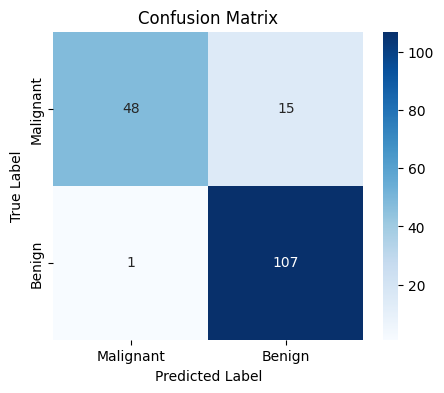

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predicted_Values)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
